In [32]:
'''
Correct the ring artifacts in the calibration data for calibration_8_41
'''

'\nCorrect the ring artifacts in the calibration data for calibration_8_41\n'

In [33]:
import os
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

from leapctype import tomographicModels

import pcct_md_diffusion.utils as utils
from pcct_md_diffusion.locations import base_input_dir

In [34]:
mu_waters = np.array([0.196, 0.192, 0.186])
display_vmins = (-50 + 1000) / 1000 * mu_waters
display_vmaxs = (50 + 1000) / 1000 * mu_waters

Loading channel 0...
Loading channel 1...
Loading channel 2...


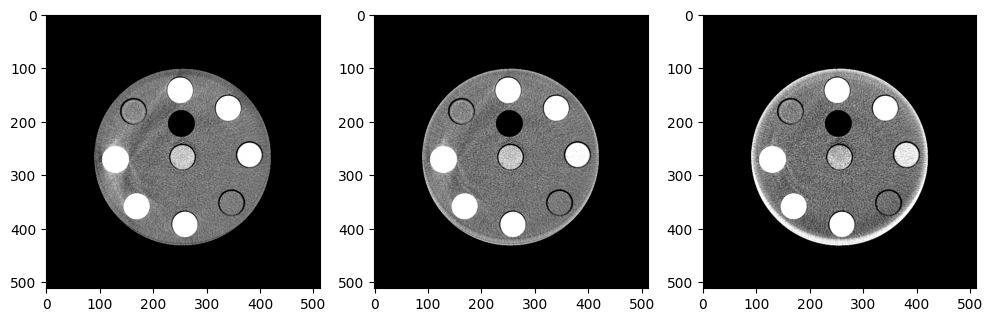

In [35]:
calibration_dir = os.path.join(base_input_dir, 'omnitom_pcd/calibration/calibration_8_41/img/1')
imgs, dx, dy, dz, sitk_ref = utils.load_image(calibration_dir, return_sitk_template=True)
imgs[imgs < -1000] = -1000

for i in range(3):
    imgs[i] = (imgs[i] + 1000) / 1000 * mu_waters[i]

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(imgs[i, 0], 'gray', vmin=display_vmins[i], vmax=display_vmaxs[i])
plt.show()


======== CT Parallel-Beam Geometry ========
Forward projecting...
number of angles: 720
number of detector elements (rows, cols): 2 x 1756
angular range: 180.000000 degrees
detector pixel size: 5.656000 mm x 0.175785 mm
center detector pixel: 0.500000, 877.500000

======== CT Volume ========
number of voxels (x, y, z): 512 x 512 x 2
voxel size: 0.601562 mm x 0.601562 mm x 5.656000 mm
FOV: [-154.000000, 154.000000] x [-154.000000, 154.000000] x [-5.656000, 5.656000]

======== Processing Settings ========
GPU processing on devices 0, 1, 2
GPU with least amount of memory: 35.161964 GB

Channel 0
Channel 1
Channel 2
(3, 720, 2, 1756)


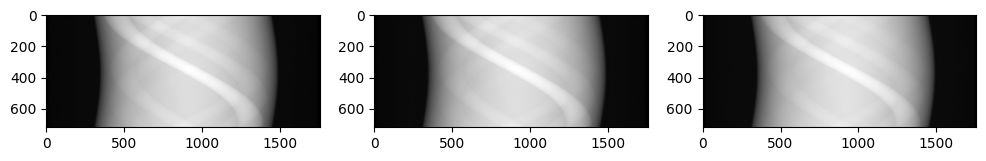

In [79]:
# forward projection
geometry_path = os.path.join(base_input_dir, 'omnitom_pcd/geometry/omnitom_3x3_parallel_fov_308.cfg')
geo = utils.load_geometry(geometry_path)
geo.nview = 720
geo.off_u = 0
geo.nx = imgs.shape[-1]
geo.ny = imgs.shape[-2]
geo.nz = imgs.shape[-3]
geo.nv = geo.nz
geo.dx = dx
geo.dy = dy
geo.dz = dz
geo.dv = dz
geo.du /= 2
geo.nu *= 2
leapct = utils.set_leapct_geometry(geo, angles_in_deg=np.arange(0, 180, 180 / 720.0).astype(np.float32))
leapct.print_parameters()

print('Forward projecting...', flush=True)
current_fp = leapct.allocate_projections()
prjs = []
for ch in range(imgs.shape[0]):
    print('Channel', ch, flush=True)
    leapct.project(current_fp, imgs[ch])
    prjs.append(np.copy(current_fp, 'C'))
prjs = np.array(prjs)

print(prjs.shape)

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(prjs[i, :, 0, :], 'gray')
plt.show()

Reconstructing...
Channel 0
Channel 1
Channel 2


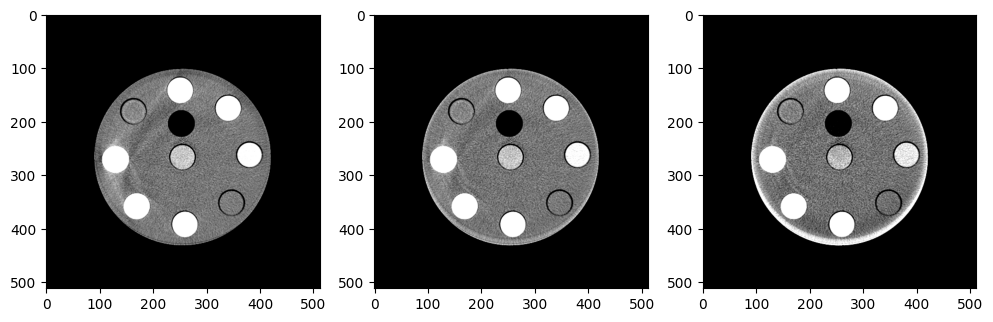

In [80]:
# validate reconstruction
print('Reconstructing...', flush=True)
fbps_origin = []
for ch in range(prjs.shape[0]):
    print('Channel', ch, flush=True)
    current_fbp = leapct.FBP(prjs[ch])
    fbps_origin.append(np.copy(current_fbp, 'C'))
fbps_origin = np.array(fbps_origin)

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(fbps_origin[i, 0], 'gray', vmin=display_vmins[i], vmax=display_vmaxs[i])
plt.show()

Boundary indices: 309 1446
Reconstructing...


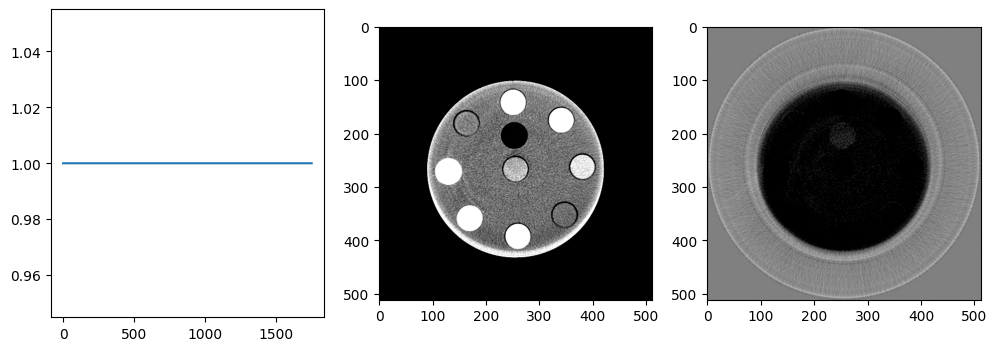

In [135]:
# test the boundary on channel 2
radius_mm = 200 / 2
left_margin = 20
right_margin = 0
magnitude = 1


radius_pixel = radius_mm / geo.du
istart = int(np.ceil((geo.nu - 1) / 2 - geo.off_u - radius_pixel))
iend = int(np.floor((geo.nu - 1) / 2 - geo.off_u + radius_pixel))
print('Boundary indices:', istart, iend)

correction_curve = np.ones(prjs.shape[-1])
# correction_curve[iend - left_margin:iend + right_margin] *= magnitude * np.linspace(0, 1, right_margin + left_margin) + 1 * np.linspace(1, 0, right_margin + left_margin)
correction_curve[iend - left_margin:iend + right_margin] *= 1 + np.cos(np.linspace(0, np.pi, right_margin + left_margin)) * (1 - magnitude) / 2 - (1 - magnitude) / 2
correction_curve[iend + right_margin:] *= magnitude


prjs_corrected = prjs.copy()
prjs_corrected[2, ...] *= correction_curve
# prjs_corrected[2, :, 0, :] += (correction_curve - 1) * 30

print('Reconstructing...', flush=True)
fbp = leapct.FBP(prjs_corrected[2])
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(correction_curve)
plt.subplot(1, 3, 2)
plt.imshow(fbp[0], 'gray', vmin=display_vmins[2], vmax=display_vmaxs[2])
plt.subplot(1, 3, 3)
# plt.imshow(fbps_origin[2, 0], 'gray', vmin=display_vmins[2], vmax=display_vmaxs[2])
plt.imshow(fbps_origin[2, 0] - fbps_origin[0, 0], 'gray', vmin=-0.01, vmax=0.01)